In [1]:
# see single_network_gw_bencharking.py in example_scripts of gwbench gitlab for original

In [2]:
from argparse import ArgumentParser

import numpy as np

from pprint import pprint as pp

from gwbench import Network, injections_CBC_params_redshift, M_of_Mc_eta, f_isco_Msolar

import corner

from bilby.gw import conversion as conv
import pandas as pd

/Users/ved/miniforge3/envs/neutron/lib/python3.12/site-packages/gwbench/basic_relations.py:20: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import GreenwichMeanSiderealTime


In [3]:
# must use: log/cos, but don't use log for Mc, don't include delta_lam_t

np.set_printoptions(linewidth=200)

# choose 'num' or 'sym' for numerical or symbolic derivatives
derivs = 'num'
inj_id = 0

# waveform
wf_model_name = 'lal_bns'
wf_other_var_dic = {'approximant':'IMRPhenomD_NRTidalv2'}


# user's choice: with respect to which parameters to take derivatives for the Fisher analysis
deriv_symbs_string = 'Mc DL tc phic iota lam_t ra dec psi'
# deriv_symbs_string = 'Mc eta DL tc phic iota lam_t delta_lam_t ra dec psi'
# deriv_symbs_string = 'Mc eta chi1z chi2z DL tc phic iota lam_t delta_lam_t ra dec psi'

# user's choice: convert derivatives to cos or log for specific variables
conv_cos = ('dec','iota')
# conv_log = ('Mc','DL','lam_t')
conv_log = ('DL','lam_t')

# if numeric  derivatives, user's decision -> leave on
use_rot = 1

# calculate SNRs, error matrices, and errors only for the network
only_net = 1

# number of cores to use for parallelize of the calc_det_responses_derivs
# = None for no parallelization, = 2,3,4,... to allocate N cores (even numbers preferred)
num_cores = None

# options for numeric derivative calculation
if derivs == 'num':
    # user's choice: switch particular partial derivatives to be analytical, options = [DL,tc,phic,ra,dec,psi]
    # otherwise set to None
    ana_deriv_symbs_string = 'DL tc phic ra dec psi'

    # choose numdifftools parameters for numerical derivatives
    step      = 1e-6
    method    = 'central'
    order     = 2

    # only relevant for symbolic derivatives
    gen_derivs = None

# options for symbolic derivative calculation
elif derivs == 'sym':

    # user's choice: switch particular partial derivatives to be analytical, options = [DL,tc,phic,ra,dec,psi]
    # otherwise set to None
    ana_deriv_symbs_string = None

    # choose numdifftools parameters for numerical derivatives
    step      = None
    method    = None
    order     = None

    # tell the code to generate symbolic derivatives as needed (turned on this tutorial)
    # the recommendation is to precompute them externally and load them for large-scale runs
    gen_derivs = True

# user's choice to generate injection parameters
mmin      = 1.0
mmax      = 2.2
chi_lo    = 0 # no spins
chi_hi    = 0

cosmo_dict = {'zmin':0, 'zmax':0.2, 'sampler':'uniform_comoving_volume_inversion'}
mass_dict  = {'dist':'uniform', 'mmin':mmin, 'mmax':mmax}
# the default waveforms above are non-precessing, hence dim=1, set dim=3 for precessing waveforms like 'IMRPhenomPv2' or 'IMRPhenomPv2_NRTidalv2'
spin_dict  = {'dim':1, 'geom':'cartesian', 'chi_lo':chi_lo, 'chi_hi':chi_hi}

redshifted = 1
num_injs   = 100
seed       = 29378
file_path  = None

injections_data = injections_CBC_params_redshift(cosmo_dict,mass_dict,spin_dict,redshifted,num_injs,seed,file_path)

############################################################################
### injection parameters
############################################################################

inj_params = {
    'Mc'    : conv.component_masses_to_chirp_mass(1.5, 1.5),
    'eta'   : 0.25,
    'chi1x' : injections_data[2][inj_id],
    'chi1y' : injections_data[3][inj_id],
    'chi1z' : injections_data[4][inj_id],
    'chi2x' : injections_data[5][inj_id],
    'chi2y' : injections_data[6][inj_id],
    'chi2z' : injections_data[7][inj_id],
    'DL'    : injections_data[8][inj_id],
    'tc'    : 0.,
    'phic'  : 0.,
    'iota'  : injections_data[9][inj_id],
    'ra'    : injections_data[10][inj_id],
    'dec'   : injections_data[11][inj_id],
    'psi'   : injections_data[12][inj_id],
    'z'     : injections_data[13][inj_id],
    }

inj_params['lam_t']       = 600.0
inj_params['delta_lam_t'] = 0.0

print('injections parameter: ', inj_params)
print()

############################################################################
### Network specification
############################################################################

# network_spec = ['CE-40_C','CE-40_S']
network_spec = 'E'

print('network spec: ', network_spec)
print()

f_lo = 1.
f_hi = f_isco_Msolar(M_of_Mc_eta(inj_params['Mc'],inj_params['eta']))
df   = 2.**-4
f    = np.arange(f_lo,f_hi+df,df)

print('f_lo:', f_lo, '   f_hi:', f_hi, '   df:', df)
print()

############################################################################
### Single Network GW Benchmarking
############################################################################

# initialize Network and do general setup
net = Network(network_spec, logger_name='CSU', logger_level='INFO')
# pass all the needed and optional variables

net.set_net_vars(wf_model_name=wf_model_name, wf_other_var_dic=wf_other_var_dic, 
                 f=f, inj_params=inj_params, deriv_symbs_string=deriv_symbs_string,
                 conv_cos=conv_cos, conv_log=conv_log, use_rot=use_rot,
                 ana_deriv_symbs_string=ana_deriv_symbs_string)

# start the actual analysis
net.calc_errors(only_net=only_net, derivs=derivs, step=step, method=method, order=order, gen_derivs=gen_derivs, num_cores=num_cores)


# ############################################################################
# ### Print results
# ############################################################################

# net.print_detectors()
# net.print_network()

# print('Fisher analysis done.')


2026-05-16 15:59:07,514 - CSU - INFO : PSDs, antenna patterns, and LPFs loaded.
2026-05-16 15:59:07,515 - CSU - INFO : Calculate numeric derivatives of detector responses.
2026-05-16 15:59:07,515 - CSU - INFO :    ET_ET1


injections parameter:  {'Mc': 1.3058258449441862, 'eta': 0.25, 'chi1x': np.float64(0.0), 'chi1y': np.float64(0.0), 'chi1z': np.float64(0.0), 'chi2x': np.float64(0.0), 'chi2y': np.float64(0.0), 'chi2z': np.float64(0.0), 'DL': np.float64(595.845227743203), 'tc': 0.0, 'phic': 0.0, 'iota': np.float64(0.2367522187410996), 'ra': np.float64(4.043179805492967), 'dec': np.float64(1.1829476432948405), 'psi': np.float64(3.277322349164817), 'z': np.float64(0.12333513379798339), 'lam_t': 600.0, 'delta_lam_t': 0.0}

network spec:  E

f_lo: 1.0    f_hi: 1465.7248970301412    df: 0.0625



2026-05-16 15:59:07,789 - CSU - INFO :    ET_ET2
2026-05-16 15:59:08,056 - CSU - INFO :    ET_ET3
2026-05-16 15:59:08,328 - CSU - INFO : Numeric derivatives of detector responses calculated.
2026-05-16 15:59:08,330 - CSU - INFO : SNRs calculated.
2026-05-16 15:59:08,330 - CSU - INFO : Calculate errors (Fisher & cov matrices).
2026-05-16 15:59:08,330 - CSU - INFO :    ET_ET1
2026-05-16 15:59:08,336 - CSU - INFO :    ET_ET2
2026-05-16 15:59:08,342 - CSU - INFO :    ET_ET3
2026-05-16 15:59:08,357 - CSU - INFO : Sky areas calculated.
2026-05-16 15:59:08,357 - CSU - INFO : Errors calculated.


In [4]:
print(net.cond_num)
print(net.cov)

1.479149501083834e+18
[[ 4.33454619e-17  4.34871206e-09  8.09368252e-13  5.77915008e-11  4.17077084e-09 -5.65373443e-12 -3.36075334e-10  7.46792905e-11 -2.30864938e-10]
 [ 4.34871206e-09  1.58248749e+01 -2.08031945e-03  1.54915720e-01  1.56608992e+01 -2.20483486e-02  1.72435436e-02  1.58196092e-01  2.75825471e-01]
 [ 8.09368252e-13 -2.08031945e-03  5.52164693e-07 -2.92452733e-05 -2.07698182e-03  1.89025820e-06 -4.84879201e-05 -2.36662963e-05 -8.38914057e-05]
 [ 5.77915008e-11  1.54915720e-01 -2.92452733e-05  3.79849086e-03  1.49767920e-01 -4.16872004e-04 -2.99028773e-03  3.55539634e-03 -2.23315135e-03]
 [ 4.17077084e-09  1.56608992e+01 -2.07698182e-03  1.49767920e-01  1.55109005e+01 -2.26528198e-02  3.22167017e-02  1.51871249e-01  2.93262422e-01]
 [-5.65373443e-12 -2.20483486e-02  1.89025820e-06 -4.16872004e-04 -2.26528198e-02  3.07224062e-03 -1.03645714e-03  8.13983570e-05 -1.78742665e-03]
 [-3.36075334e-10  1.72435436e-02 -4.84879201e-05 -2.99028773e-03  3.22167017e-02 -1.03645714e-0

[1.30582584 6.39692966]


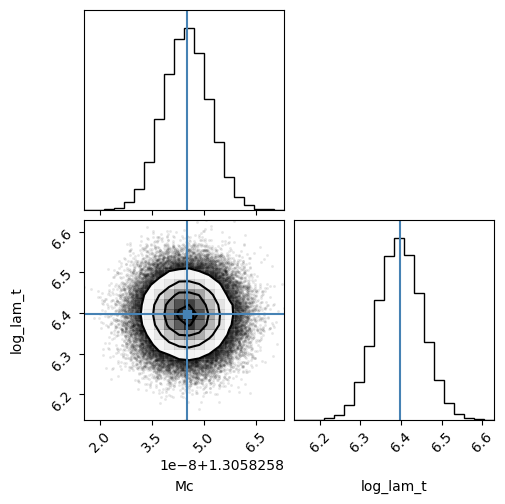

In [5]:
keep = ['Mc', 'log_lam_t']

idx = [list(net.deriv_variables).index(p) for p in keep]
cov_marginal = net.cov[np.ix_(idx, idx)]

mean_marginal = np.array([
    net.inj_params['Mc'],
    np.log(net.inj_params['lam_t'])
])

print(mean_marginal)
# print(cov_marginal)

samples = np.random.multivariate_normal(mean_marginal, cov_marginal, size=100000)

fig = corner.corner(samples, labels=['Mc', 'log_lam_t'], truths=mean_marginal)